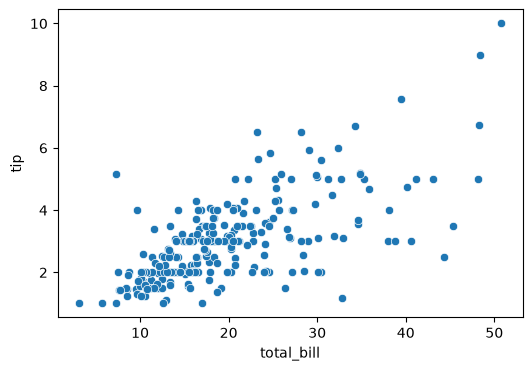

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")
titanic = sns.load_dataset("titanic")

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=ax)
plt.show()

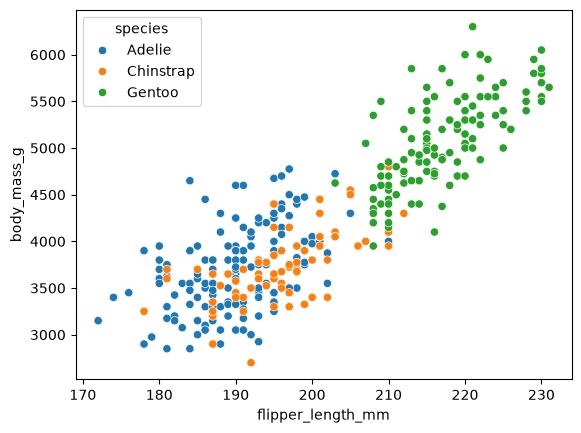

In [4]:
fig, ax = plt.subplots()
sns.scatterplot(data = penguins, x = "flipper_length_mm", y = "body_mass_g", hue = "species", ax = ax)
plt.show()

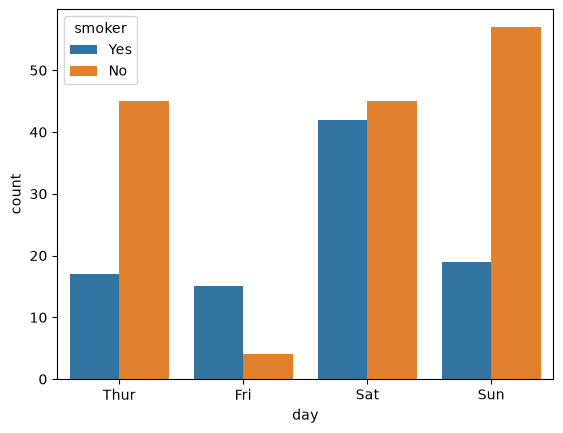

In [5]:
fig, ax = plt.subplots()
sns.countplot(data = tips, x = "day", hue = "smoker", ax = ax)
plt.show()

### Tri argumenta koja stvarno koristiš ispod:
- bins — broj kanti
- kde=True — doda glatku krivu preko histograma
- multiple= — "layer" (podrazumevano, preklopljeno), "stack" (naslagano), "dodge" (jedan pored drugog)

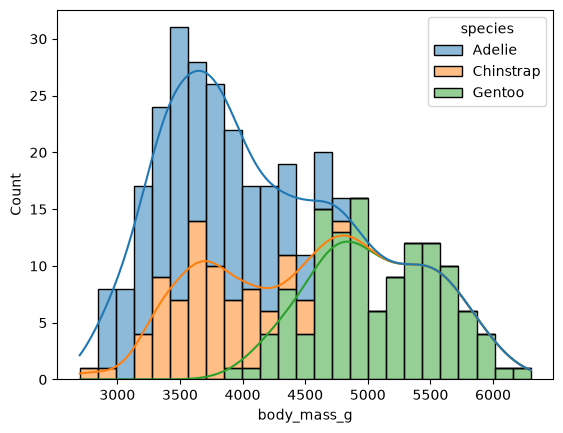

In [17]:
fig, ax = plt.subplots()
sns.histplot(data = penguins, x = "body_mass_g", hue = "species", bins = 25, alpha = 0.5, ax = ax, kde = True, multiple = "stack")
plt.show()

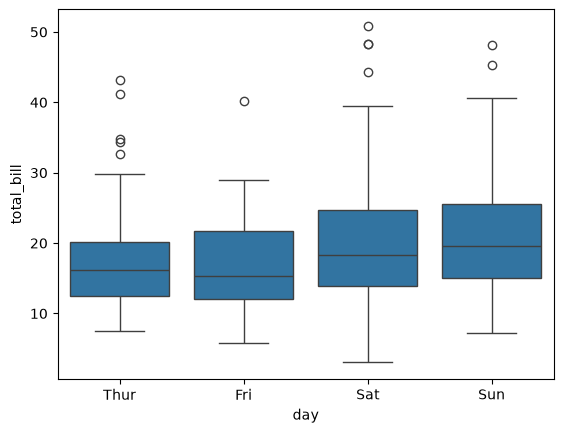

In [16]:
fig, ax = plt.subplots()
sns.boxplot(data = tips, x = "day", y = "total_bill", ax = ax)
plt.show()

In [13]:
print(tips["total_bill"].describe())

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


### ZA ISPOD
- HUE - ZA BOJE
- STYLE - ZA OBLIK MARKERA NA CRTEZU
- SIZE - ZA VELICINU MARKERA

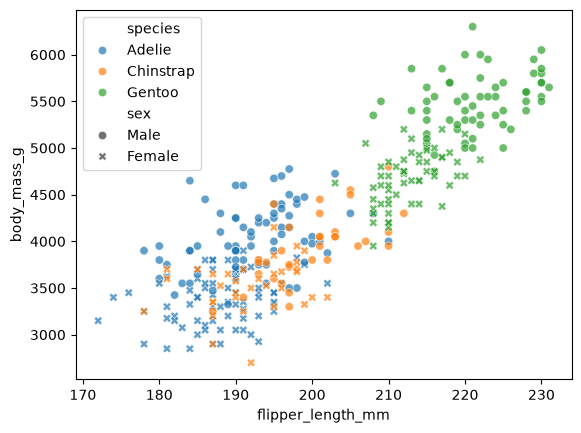

In [15]:
fig, ax = plt.subplots()
sns.scatterplot(data = penguins, x = "flipper_length_mm", y = "body_mass_g", 
                hue = "species", style = "sex", alpha = 0.7, ax = ax)
plt.show()

### Ovde se barplot i countplot razlikuju tj ovamo smo imali samo bar u matplotlibu ali ovde imamo i jedno i drugo
- BAR - racuna prosek neke numericke kolone po kategoriji (kategorija je kolona tj klasa koja se prosledi kao x)
- COUNT - radi kao bar koji smo koristili u mpl daje mu se samo x dok y sracuna sam tako sto broji pojavljivanja vrednosti iz kolone x

Crne crtice na vrhu stubića u barplot su interval poverenja, računat bootstrap-om. Ako ti smeta ili usporava, errorbar=None.

Pravilo: countplot = koliko ih ima. barplot = kolika im je prosečna vrednost.

Da promeniš statistiku: sns.barplot(..., estimator="median").

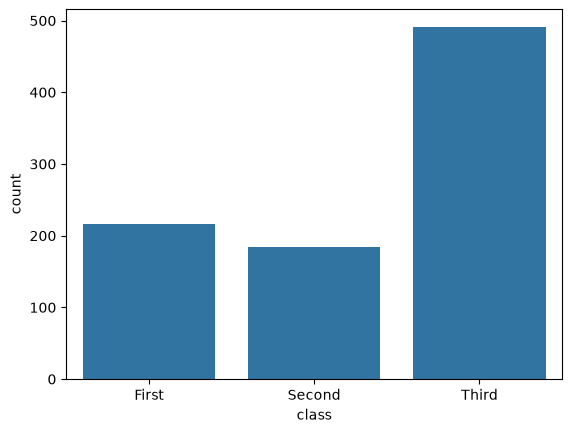

In [20]:
fig, ax = plt.subplots()
sns.countplot(data = titanic, x = "class", ax = ax)
plt.show()

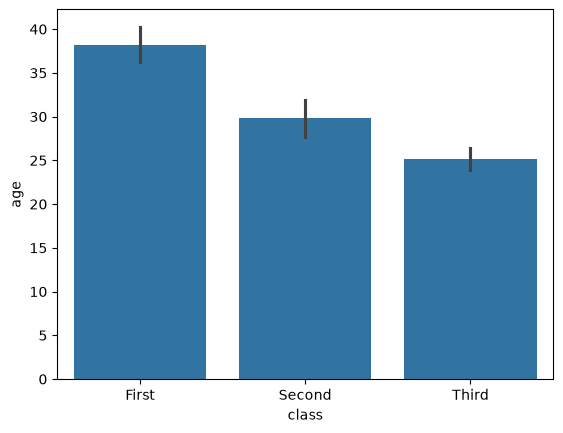

In [23]:
fig, ax = plt.subplots()
sns.barplot(data = titanic, x = "class", y = "age", ax = ax)
plt.show()

### Objasnjeni parametri za heatmap, u sustini korisna da se vidi da li su 2 kolone sa koleracijom preko 0.9 jedna je visak
- annot=True — ispiše brojeve u ćelije. Bez toga gledaš boje i pogađaš.
- fmt=".2f" — dve decimale
- vmin=-1, vmax=1 — ovo je važno. Bez toga Seaborn skalira boje prema opsegu tvojih podataka, pa korelacija 0.3 može ispasti jarko crvena. Fiksiraj opseg da bi boje značile isto na svakom grafiku.
- cmap="coolwarm" — divergentna paleta, nula je bela. Za korelacije uvek divergentna, nikad "viridis".

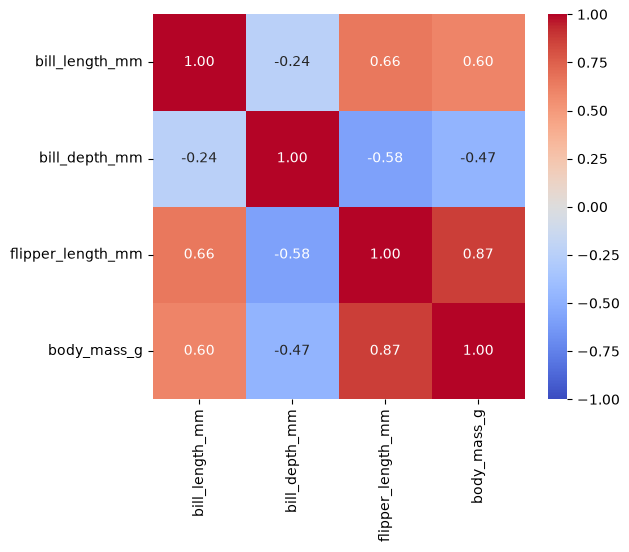

In [28]:
korel = penguins.select_dtypes(include = "number").corr()
fig, ax = plt.subplots(figsize = (6,5))
sns.heatmap(korel, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1, ax = ax)
plt.show()

### Pairplot (figure-level funkcija)
**Mreža svih parova numeričkih kolona. Na dijagonali raspodela svake kolone, van dijagonale scatter svakog para.**

Obrati pažnju da nema fig, ax ni ax=. O tome odmah u sledećem odeljku.

1. Korisni argumenti:

- vars=["bill_length_mm", "flipper_length_mm"] — samo određene kolone
- diag_kind="kde" — glatke krive na dijagonali umesto histograma
- corner=True — samo donji trougao (gornji je ogledalo donjeg, ionako suvišan)

2. Zamka: za 20 kolona dobiješ 400 podgrafika. Notebook se zaledi, a ti ništa ne vidiš. Pravilo: do 6-7 kolona, inače vars=.

3. U ML-u: brz pregled razdvojivosti klasa i odnosa među feature-ima. Na penguins sa hue="species" odmah vidiš da je Gentoo linearno odvojiv, a Adelie i Chinstrap se razdvajaju tek po dužini kljuna.

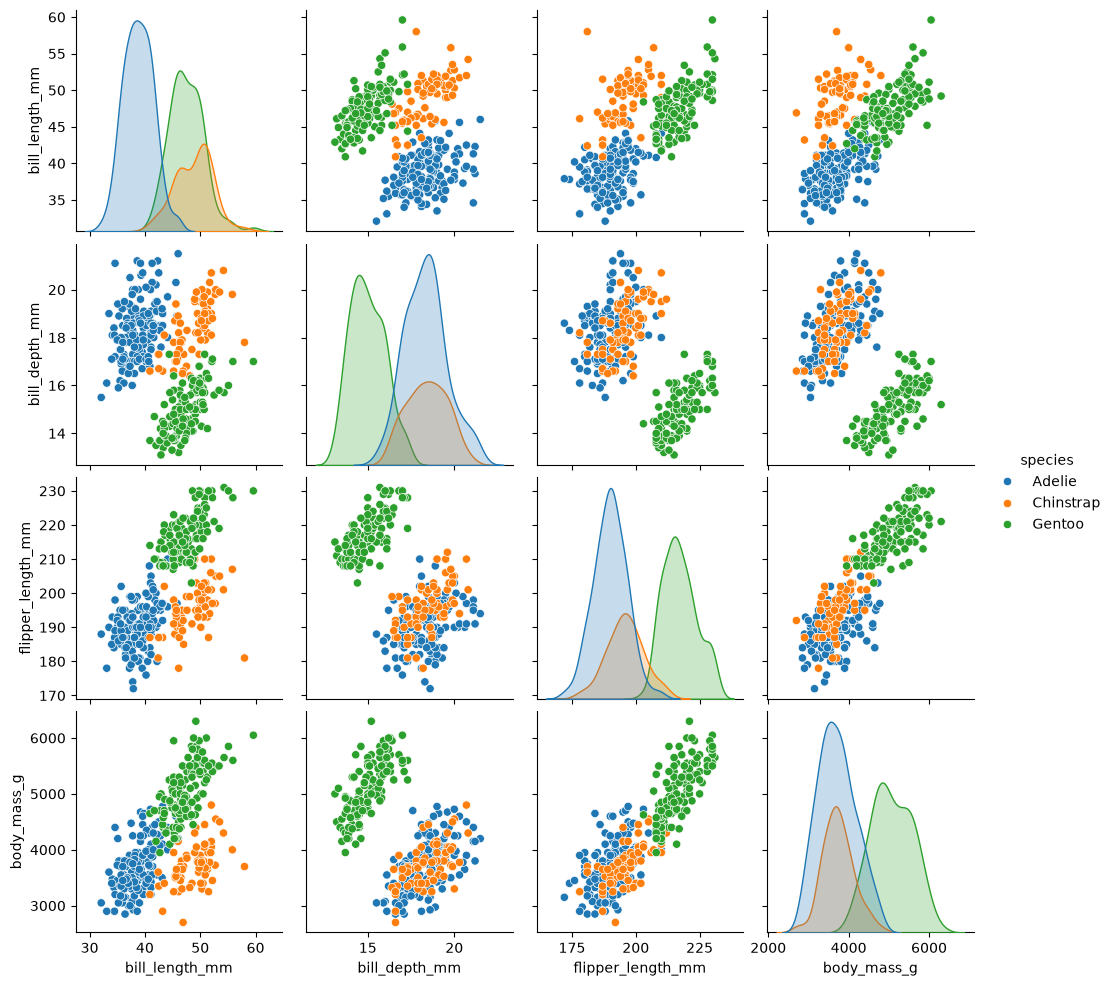

In [30]:
sns.pairplot(penguins, hue = "species")
#NEMAMO FIG I AX JER ON SAM PRAVI SVE ALI ZATO OPREZNO SA BROJEM KOLONA
plt.show()

### Figure level ne koristi ax vec pravi celu sliku tj figuru sam pa ce onda kao u primeru catplot da se stavi g = i da se iz g pozivaju sva podesavanja

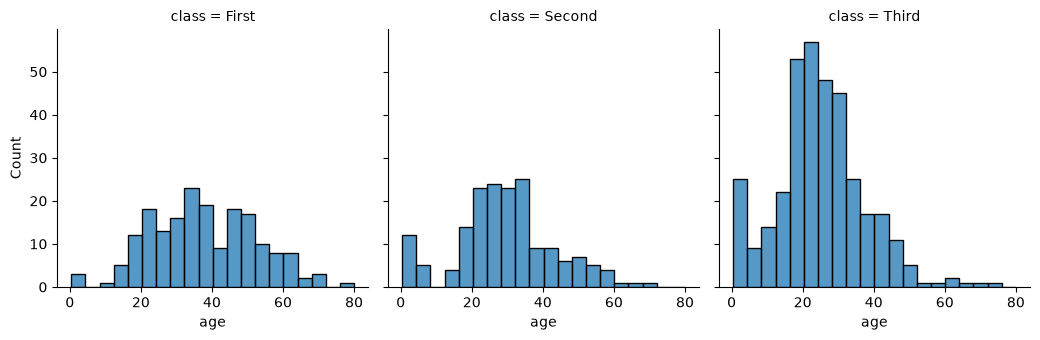

In [32]:
sns.displot(data=titanic, x="age", col="class", height=3.5, aspect=1)
#SAM JE NAPRAVIO POSEBAN HISTOGRAM ZA SVAKU VREDNOST IZ CLASS
plt.show()

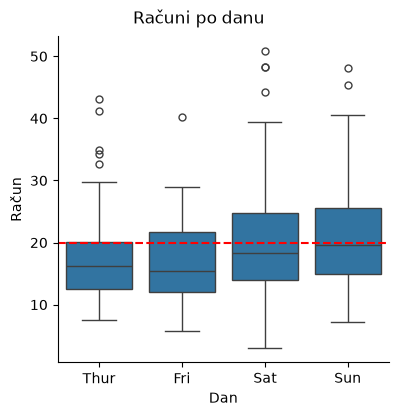

In [33]:
g = sns.catplot(data=tips, x="day", y="total_bill", kind="box", height=4)

g.figure.suptitle("Računi po danu", y=1.03)   # naslov cele figure
g.set_axis_labels("Dan", "Račun")             # oznake osa
g.set_titles("{col_name}")                    # šablon naslova faseta
g.axes.flat[0].axhline(20, ls="--", c="red")  # pristup pojedinačnom ax
plt.show()

### Nivo 1


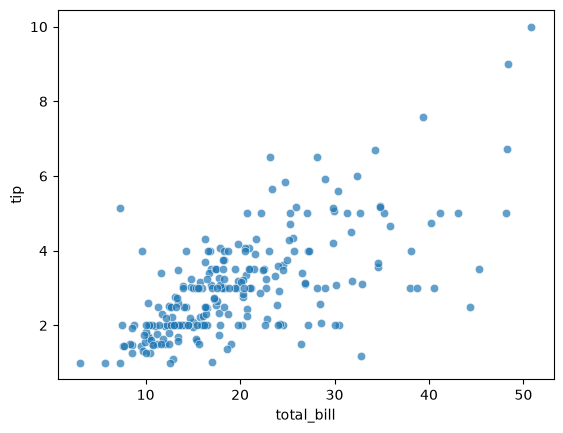

In [37]:
fig, ax = plt.subplots()
sns.scatterplot(data = tips, x = "total_bill", y = "tip", ax = ax, alpha = 0.7)
plt.show()

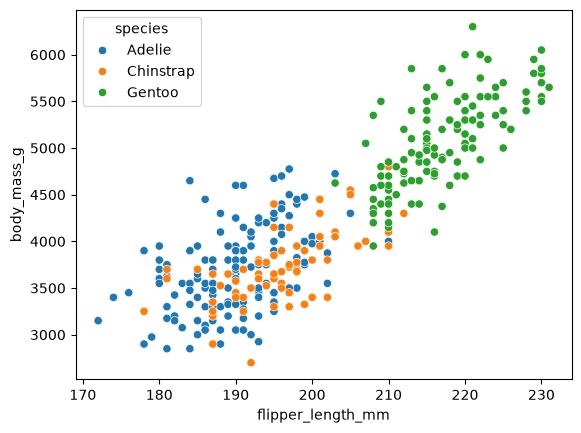

In [42]:
fig, ax = plt.subplots()
sns.scatterplot(data = penguins,x = "flipper_length_mm", y = "body_mass_g" ,hue = "species", ax = ax)
plt.show()

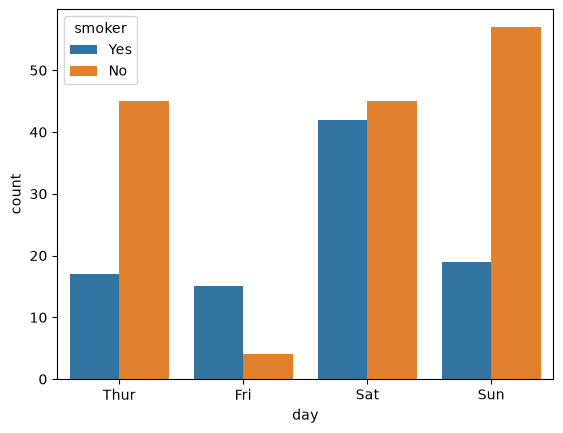

In [43]:
fig, ax = plt.subplots()
sns.countplot(data = tips, x = "day", hue = "smoker", ax = ax)
plt.show()

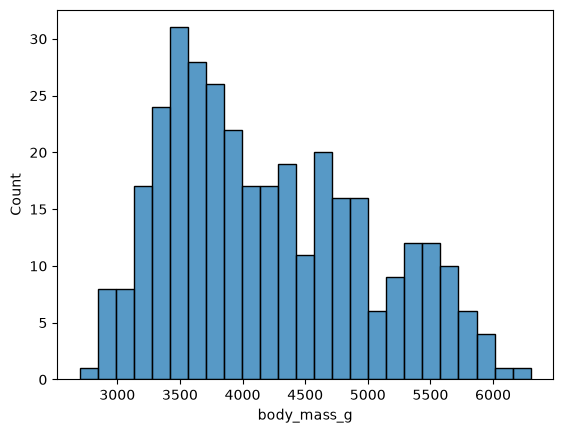

In [44]:
fig, ax = plt.subplots()
sns.histplot(data = penguins, bins = 25, x = "body_mass_g", ax = ax)
plt.show()

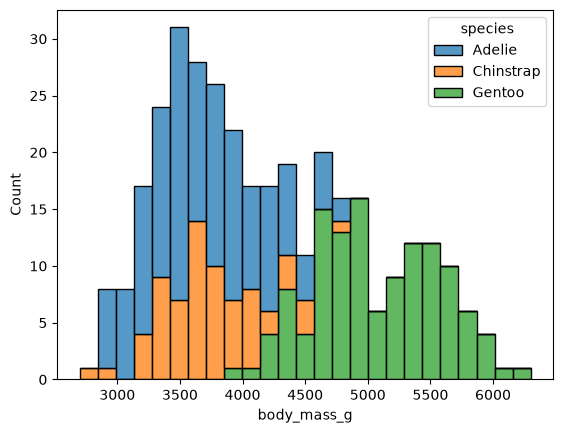

In [46]:
fig, ax = plt.subplots()
sns.histplot(data = penguins, bins = 25, x = "body_mass_g", ax = ax, hue = "species", multiple = "stack")
plt.show()

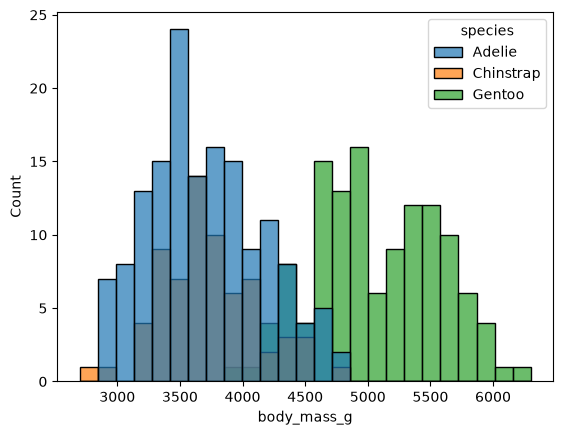

In [47]:
fig, ax = plt.subplots()
sns.histplot(data = penguins, bins = 25, x = "body_mass_g", ax = ax, hue = "species", alpha = 0.7)
plt.show()

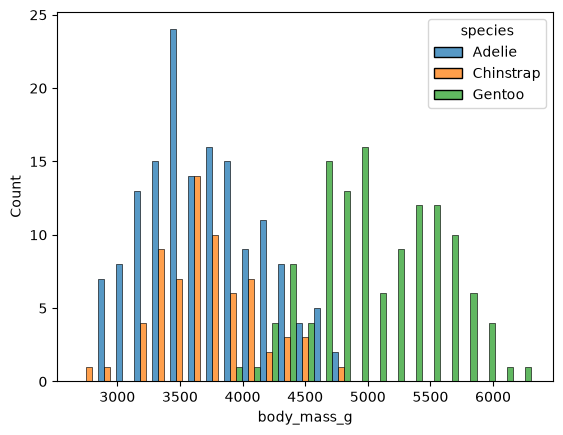

In [48]:
fig, ax = plt.subplots()
sns.histplot(data = penguins, bins = 25, x = "body_mass_g", ax = ax, hue = "species", multiple = "dodge")
plt.show()

### Nivo 2

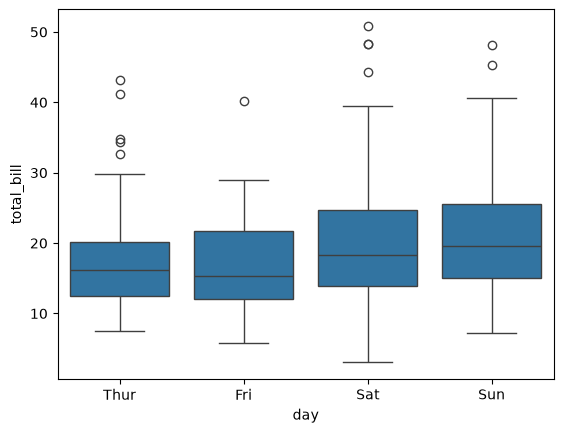

      count       mean       std   min      25%    50%      75%    max
day                                                                   
Thur   62.0  17.682742  7.886170  7.51  12.4425  16.20  20.1550  43.11
Fri    19.0  17.151579  8.302660  5.75  12.0950  15.38  21.7500  40.17
Sat    87.0  20.441379  9.480419  3.07  13.9050  18.24  24.7400  50.81
Sun    76.0  21.410000  8.832122  7.25  14.9875  19.63  25.5975  48.17


In [50]:
fig, ax = plt.subplots()
sns.boxplot(data = tips, x = "day", y = "total_bill", ax = ax)
plt.show()

print(tips.groupby("day", observed = True)["total_bill"].describe())

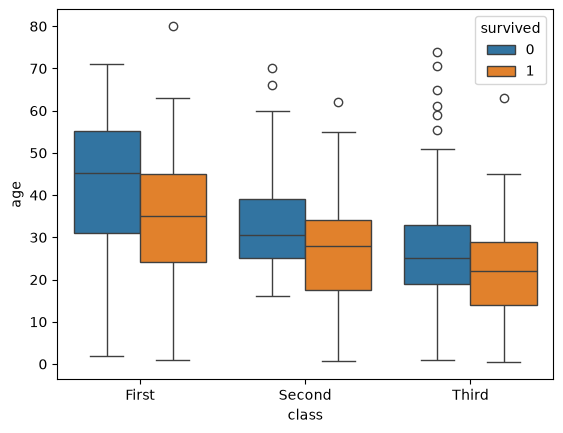

In [52]:
fig, ax = plt.subplots()
sns.boxplot(data = titanic, x = "class", y = "age", hue = "survived", ax = ax)
plt.show()

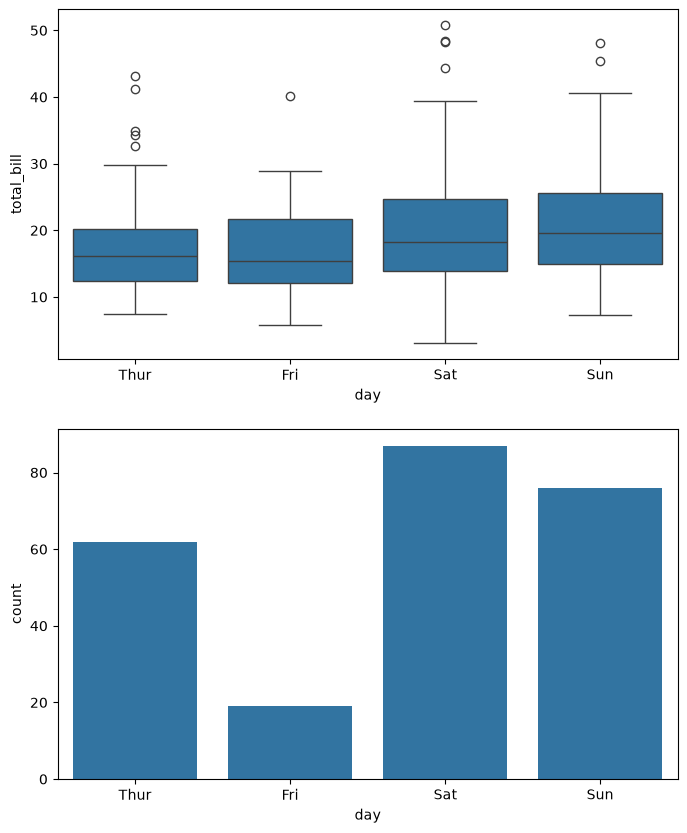

In [56]:
fig, ax = plt.subplots(2, 1, figsize = (8, 10))
sns.boxplot(data = tips, x = "day", y = "total_bill", ax =  ax[0])
sns.countplot(data = tips, x = "day")
plt.show()

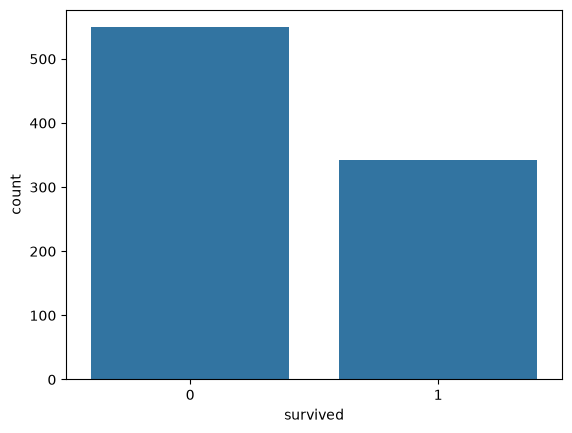

In [58]:
fig, ax = plt.subplots()
sns.countplot(data = titanic, x = "survived", ax = ax)
plt.show()

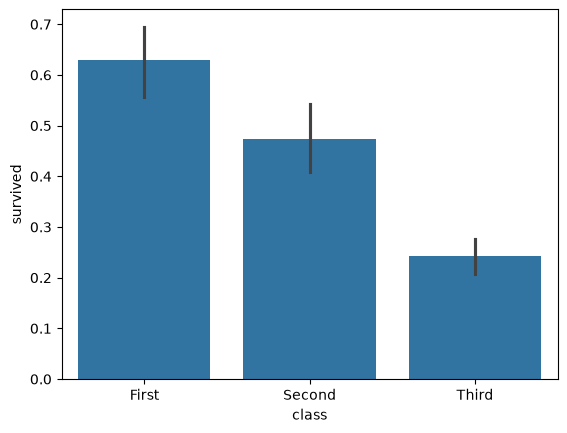

In [60]:
fig, ax = plt.subplots()
sns.barplot(data = titanic, x = "class", y = "survived", ax = ax)
plt.show()

### Nivo 3

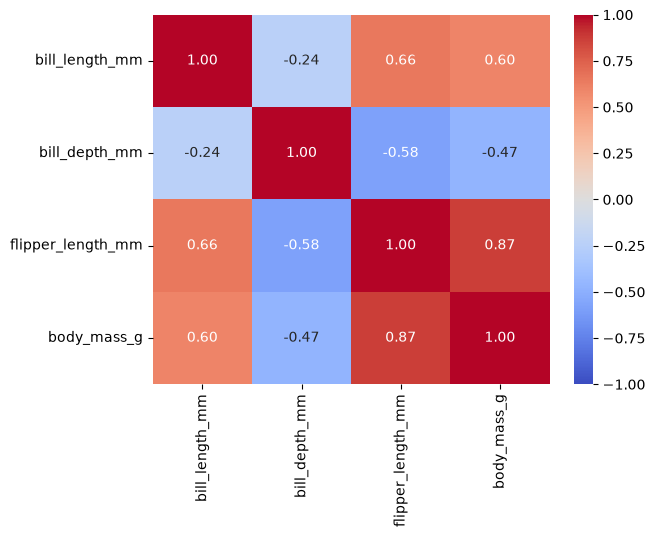

In [66]:
num = penguins.select_dtypes(include = "number").corr()
#print(num)
sns.heatmap(data = num, cmap = "coolwarm", vmax = 1, vmin = -1, annot = True, fmt = ".2f")
plt.show()

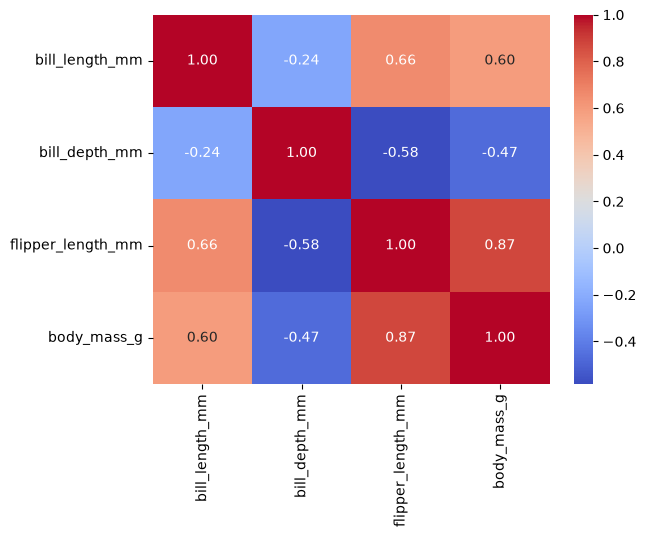

In [67]:
num = penguins.select_dtypes(include = "number").corr()
#print(num)
sns.heatmap(data = num, cmap = "coolwarm",  annot = True, fmt = ".2f")
plt.show()

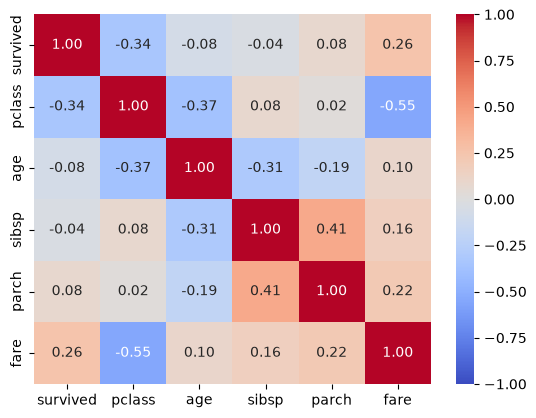

In [68]:
num = titanic.select_dtypes(include = "number").corr()
sns.heatmap(data = num, annot = True, fmt = ".2f", vmin = -1, vmax = 1, cmap = "coolwarm")
plt.show()

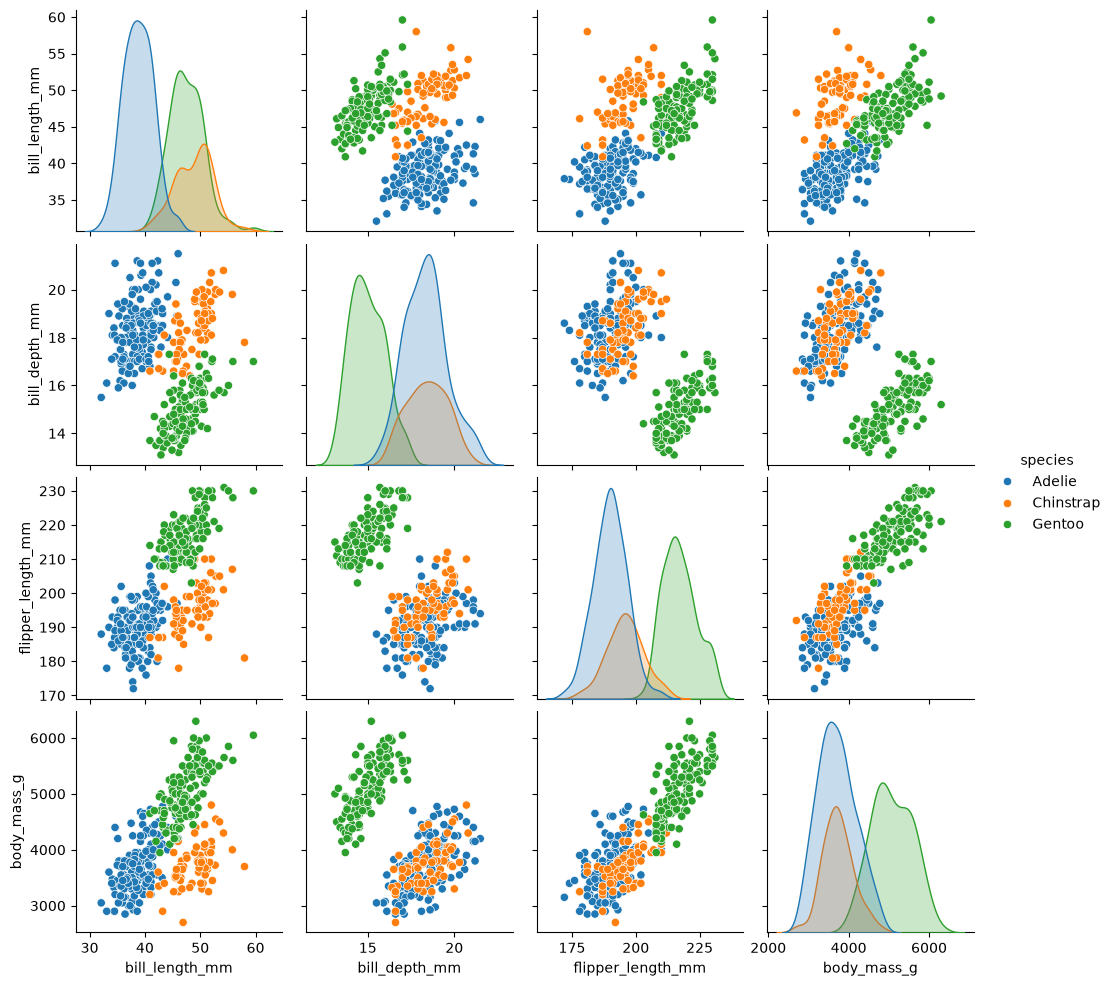

In [71]:
sns.pairplot(data = penguins, hue = "species")
plt.show()

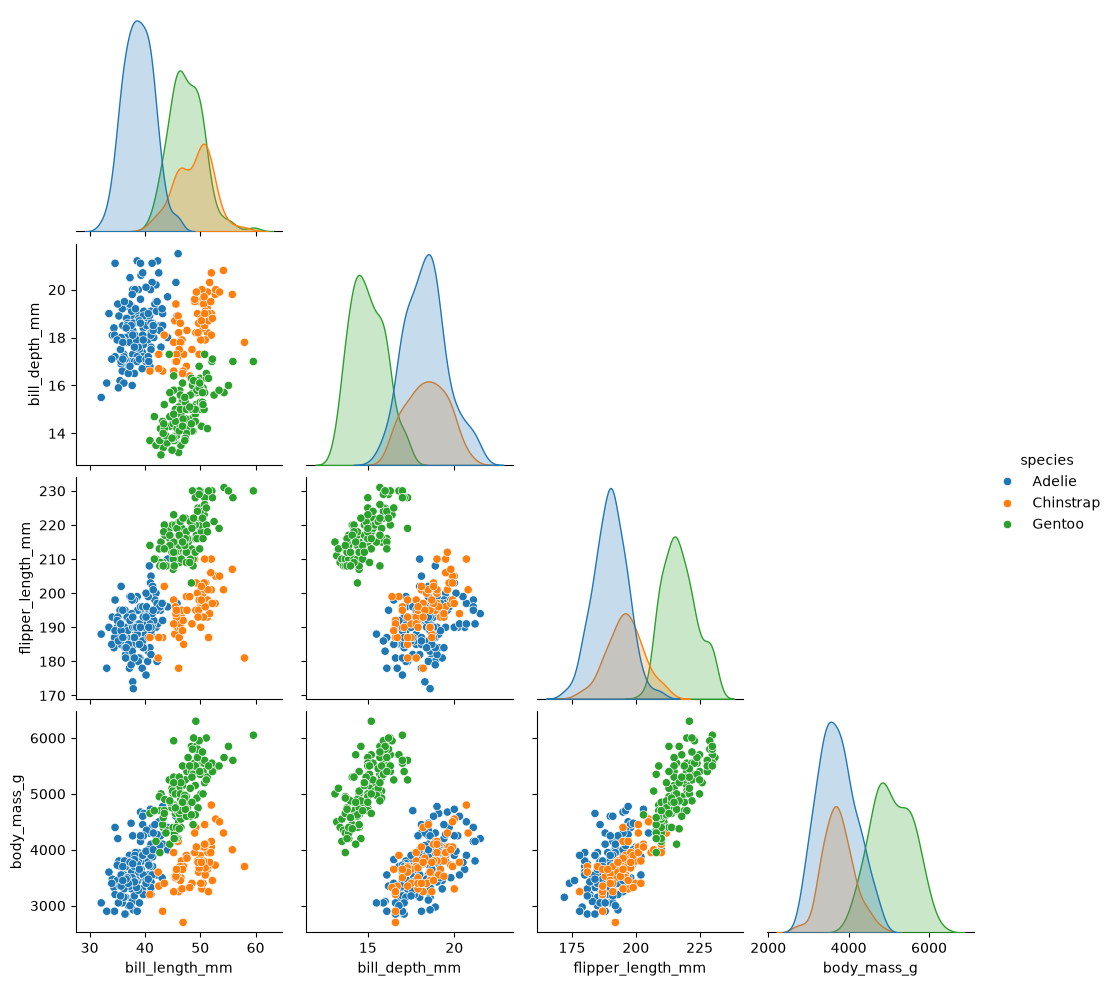

In [72]:
sns.pairplot(data = penguins, hue = "species", corner = True, diag_kind = "kde")

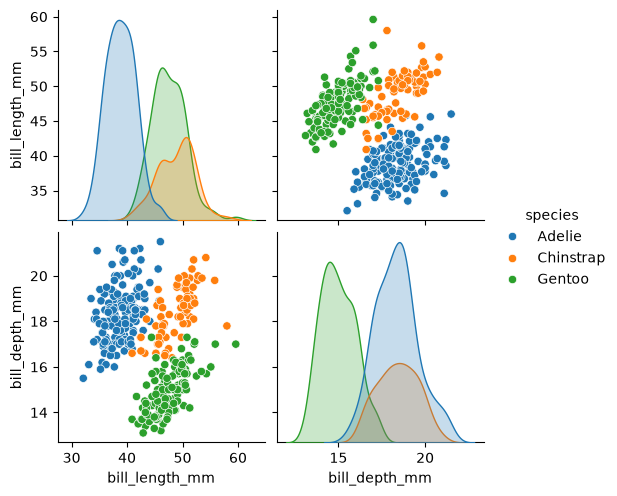

In [73]:
sns.pairplot(data = penguins, vars = ["bill_length_mm", "bill_depth_mm"], hue = "species")
plt.show()

### Nivo 4